In [1]:
# Load packages
library(dplyr)
library(tidyr)
library(hms)
library(lubridate)
library(ggplot2)
library(purrr)
library(patchwork)
library(tidyverse)
# library(reshape2)
library(stringr)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following object is masked from ‘package:hms’:

    hms


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.1     ✔ stringr 1.5.2
✔ readr   2.1.5     ✔ tibble  3.3.0
── Conflicts ──────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()  masks stats::filter()
✖ lubridate::hms() masks hms::hms()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
getwd()

[1] "/home/strawperry/Documents/Masters/growth_curves"

In [3]:
# Load files
## classical M9 medium
pattern_classic <- "^101225_.*h\\-classic.csv$"   # files starting with DATE and ending in h.csv

## modified M9 medium
pattern_modif <- "^101225_.*h\\-modif.csv$"   # files starting with DATE and ending in h.csv

In [5]:
# Check if files were assigned correctly 
files_classic <- list.files(pattern = pattern_classic, full.names = TRUE)
files_modif   <- list.files(pattern = pattern_modif,   full.names = TRUE)
files_classic
files_modif

[1] "./101225_0h-classic.csv"  "./101225_24h-classic.csv"
[3] "./101225_2h-classic.csv"  "./101225_30h-classic.csv"
[5] "./101225_48h-classic.csv" "./101225_4h-classic.csv" 
[7] "./101225_6h-classic.csv"  "./101225_8h-classic.csv"

[1] "./101225_0h-modif.csv"  "./101225_24h-modif.csv" "./101225_2h-modif.csv" 
[4] "./101225_30h-modif.csv" "./101225_48h-modif.csv" "./101225_4h-modif.csv" 
[7] "./101225_6h-modif.csv"  "./101225_8h-modif.csv"

In [6]:
## ---- Function to process a single plate file ----
process_plate_file <- function(file) {

  ## Extract incubation time (hours) from filename
  ## Example: 101225_24h-classic.csv -> 24
  time_hr <- sub(".*_(\\d+)h.*", "\\1", basename(file))
  time_hr <- as.numeric(time_hr)

  ## Import raw plate data
  ## - First row is skipped (instrument metadata)
  ## - No header row
  raw <- read.csv(
    file,
    header = FALSE,
    skip = 1,
    na.strings = c("", "NA")
  )

  ## Use first column as row identifiers (A–H)
  rownames(raw) <- raw$V1
  raw <- raw[, -1]

  ## Standardize plate columns (1–12)
  colnames(raw) <- as.character(1:12)

  ## Convert rownames to an explicit column
  raw2 <- raw %>%
    rownames_to_column("Row")

  ## Convert plate to long format (Row + Column -> Well)
  long <- raw2 %>%
    pivot_longer(
      cols      = -Row,
      names_to  = "Col",
      values_to = "Value"
    ) %>%
    mutate(
      Well = paste0(Row, Col)
    ) %>%
    select(Well, Value) %>%
    filter(!is.na(Value) & Value != "<NA>")

  ## Convert decimal comma to decimal point and cast to numeric
  long$Value <- as.numeric(gsub(",", ".", long$Value))

  ## Convert back to wide format:
  ## - One row per time point
  ## - One column per well (A1–H12)
  wide <- long %>%
    pivot_wider(
      names_from  = Well,
      values_from = Value
    )

  ## Add time column as the first column
  wide <- wide %>%
    mutate(Time_hr = time_hr, .before = 1)

  return(wide)
}

In [7]:
## ---- Process all files by medium ----
## map_dfr() binds all time points into one dataframe per medium

classic_df <- map_dfr(
  files_classic,
  process_plate_file
) %>%
  mutate(Medium = "Classic M9")
classic_df

modif_df <- map_dfr(
  files_modif,
  process_plate_file
) %>%
  mutate(Medium = "Modified M9")
modif_df

Time_hr,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H4,H5,H6,H7,H8,H9,H10,H11,H12,Medium
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,0.064,0.061,0.062,0.071,0.092,0.062,0.060,0.060,0.061,⋯,0.043,0.047,0.052,0.044,0.046,0.050,0.049,0.049,0.048,Classic M9
24,0.220,0.234,0.228,0.366,0.332,0.314,0.234,0.224,0.248,⋯,0.044,0.048,0.046,0.048,0.045,0.051,0.070,0.049,0.059,Classic M9
2,0.066,0.067,0.055,0.079,0.066,0.065,0.061,0.055,0.063,⋯,0.045,0.047,0.052,0.044,0.047,0.049,0.048,0.048,0.048,Classic M9
30,0.231,0.235,0.227,0.381,0.335,0.318,0.230,0.225,0.246,⋯,0.044,0.048,0.044,0.052,0.045,0.050,0.050,0.049,0.057,Classic M9
48,0.240,0.185,0.213,0.332,0.309,0.285,0.184,0.185,0.209,⋯,0.044,0.045,0.043,0.051,0.050,0.052,0.054,0.054,0.051,Classic M9
4,0.082,0.084,0.076,0.082,0.078,0.080,0.067,0.059,0.069,⋯,0.047,0.046,0.052,0.045,0.049,0.059,0.045,0.048,0.048,Classic M9
6,0.137,0.138,0.137,0.141,0.130,0.124,0.099,0.094,0.096,⋯,0.039,0.042,0.040,0.050,0.049,0.050,0.049,0.049,0.048,Classic M9
8,0.157,0.162,0.159,0.176,0.208,0.164,0.119,0.110,0.121,⋯,0.044,0.047,0.045,0.060,0.057,0.050,0.054,0.051,0.104,Classic M9


Time_hr,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H4,H5,H6,H7,H8,H9,H10,H11,H12,Medium
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,0.062,0.063,0.060,0.063,0.061,0.067,0.063,0.061,0.062,⋯,0.040,0.040,0.050,0.042,0.041,0.049,0.049,0.049,0.048,Modified M9
24,0.256,0.237,0.231,0.347,0.363,0.375,0.201,0.207,0.212,⋯,0.046,0.038,0.041,0.052,0.049,0.056,0.050,0.040,0.041,Modified M9
2,0.062,0.067,0.067,0.064,0.065,0.063,0.055,0.059,0.062,⋯,0.042,0.041,0.050,0.041,0.042,0.049,0.049,0.049,0.048,Modified M9
30,0.252,0.242,0.244,0.354,0.385,0.379,0.202,0.193,0.198,⋯,0.044,0.040,0.043,0.050,0.048,0.049,0.050,0.046,0.048,Modified M9
48,0.249,0.250,0.246,0.360,0.372,0.375,0.117,0.164,0.172,⋯,0.043,0.043,0.045,0.054,0.049,0.049,0.049,0.051,0.049,Modified M9
4,0.143,0.081,0.083,0.084,0.081,0.076,0.060,0.065,0.069,⋯,0.043,0.041,0.051,0.043,0.042,0.055,0.049,0.048,0.048,Modified M9
6,0.116,0.116,0.109,0.113,0.110,0.113,0.084,0.084,0.096,⋯,0.040,0.038,0.040,0.051,0.049,0.045,0.048,0.046,0.047,Modified M9
8,0.164,0.154,0.155,0.163,0.168,0.161,0.110,0.110,0.117,⋯,0.047,0.041,0.041,0.057,0.054,0.083,0.048,0.048,0.041,Modified M9


In [8]:
## ---- Combine both media into a single dataset ----
all_growth <- bind_rows(classic_df, modif_df) %>%
  arrange(Medium, Time_hr)
all_growth

Time_hr,A1,A2,A3,A4,A5,A6,A7,A8,A9,⋯,H4,H5,H6,H7,H8,H9,H10,H11,H12,Medium
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
0,0.064,0.061,0.062,0.071,0.092,0.062,0.060,0.060,0.061,⋯,0.043,0.047,0.052,0.044,0.046,0.050,0.049,0.049,0.048,Classic M9
2,0.066,0.067,0.055,0.079,0.066,0.065,0.061,0.055,0.063,⋯,0.045,0.047,0.052,0.044,0.047,0.049,0.048,0.048,0.048,Classic M9
4,0.082,0.084,0.076,0.082,0.078,0.080,0.067,0.059,0.069,⋯,0.047,0.046,0.052,0.045,0.049,0.059,0.045,0.048,0.048,Classic M9
6,0.137,0.138,0.137,0.141,0.130,0.124,0.099,0.094,0.096,⋯,0.039,0.042,0.040,0.050,0.049,0.050,0.049,0.049,0.048,Classic M9
8,0.157,0.162,0.159,0.176,0.208,0.164,0.119,0.110,0.121,⋯,0.044,0.047,0.045,0.060,0.057,0.050,0.054,0.051,0.104,Classic M9
24,0.220,0.234,0.228,0.366,0.332,0.314,0.234,0.224,0.248,⋯,0.044,0.048,0.046,0.048,0.045,0.051,0.070,0.049,0.059,Classic M9
30,0.231,0.235,0.227,0.381,0.335,0.318,0.230,0.225,0.246,⋯,0.044,0.048,0.044,0.052,0.045,0.050,0.050,0.049,0.057,Classic M9
48,0.240,0.185,0.213,0.332,0.309,0.285,0.184,0.185,0.209,⋯,0.044,0.045,0.043,0.051,0.050,0.052,0.054,0.054,0.051,Classic M9
0,0.062,0.063,0.060,0.063,0.061,0.067,0.063,0.061,0.062,⋯,0.040,0.040,0.050,0.042,0.041,0.049,0.049,0.049,0.048,Modified M9


In [6]:
od_tp <- all_data

In [9]:
## ---- Helper function: reshape and annotate OD data ----
reshape_od <- function(df) {

  df %>%
    ## Convert plate from wide (A1–H12) to long format
    pivot_longer(
      cols      = -c(Time_hr, Medium),
      names_to  = "Well",
      values_to = "OD"
    ) %>%
    
    ## Annotate experimental structure
    mutate(
      ## Clean well IDs defensively
      Well = str_trim(Well),

      ## Extract plate coordinates
      Row = str_extract(Well, "^[A-H]"),
      Col = as.numeric(str_extract(Well, "\\d+")),

      ## Carbon source by column grouping
      Carbon = case_when(
        Col %in% c(1, 2, 3) ~ "M9_GLU",
        Col %in% c(4, 5, 6) ~ "M9_SIA",
        Col %in% c(7, 8, 9) ~ "M9",
        TRUE                ~ NA_character_
      ),

      ## Strain identity by row
      Strain = case_when(
        Row %in% c("A", "B", "C") ~ "USA300",
        Row %in% c("E", "F", "G") ~ "HC-B1",
        Row == "H"                ~ "Blank",
        TRUE                      ~ NA_character_
      ),

      ## Ensure OD is numeric
      OD = as.numeric(OD)
    )
}

## ---- Apply reshaping to the full dataset ----
od_tp_long <- reshape_od(all_growth)

## ---- Final sanity checks ----
table(od_tp_long$Medium)
table(od_tp_long$Carbon)
table(od_tp_long$Strain)
unique(od_tp_long$Time_hr)


 Classic M9 Modified M9 
        768         768 


    M9 M9_GLU M9_SIA 
   384    384    384 


 Blank  HC-B1 USA300 
   192    576    576 

[1]  0  2  4  6  8 24 30 48

In [10]:
head(od_tp_long)

Time_hr,Medium,Well,OD,Row,Col,Carbon,Strain
<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
0,Classic M9,A1,0.064,A,1,M9_GLU,USA300
0,Classic M9,A2,0.061,A,2,M9_GLU,USA300
0,Classic M9,A3,0.062,A,3,M9_GLU,USA300
0,Classic M9,A4,0.071,A,4,M9_SIA,USA300
0,Classic M9,A5,0.092,A,5,M9_SIA,USA300
0,Classic M9,A6,0.062,A,6,M9_SIA,USA300


In [11]:
# Remove unwanted wells
od_tp_long2 <- od_tp_long %>%
  filter(
    !Row %in% "D", !Col %in% c(10, 11, 12))
head(od_tp_long2)

Time_hr,Medium,Well,OD,Row,Col,Carbon,Strain
<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,<chr>
0,Classic M9,A1,0.064,A,1,M9_GLU,USA300
0,Classic M9,A2,0.061,A,2,M9_GLU,USA300
0,Classic M9,A3,0.062,A,3,M9_GLU,USA300
0,Classic M9,A4,0.071,A,4,M9_SIA,USA300
0,Classic M9,A5,0.092,A,5,M9_SIA,USA300
0,Classic M9,A6,0.062,A,6,M9_SIA,USA300


In [12]:
write_tsv(od_tp_long2, "saureus_m9_classXmodif_101225.tsv")

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_smooth()`).”


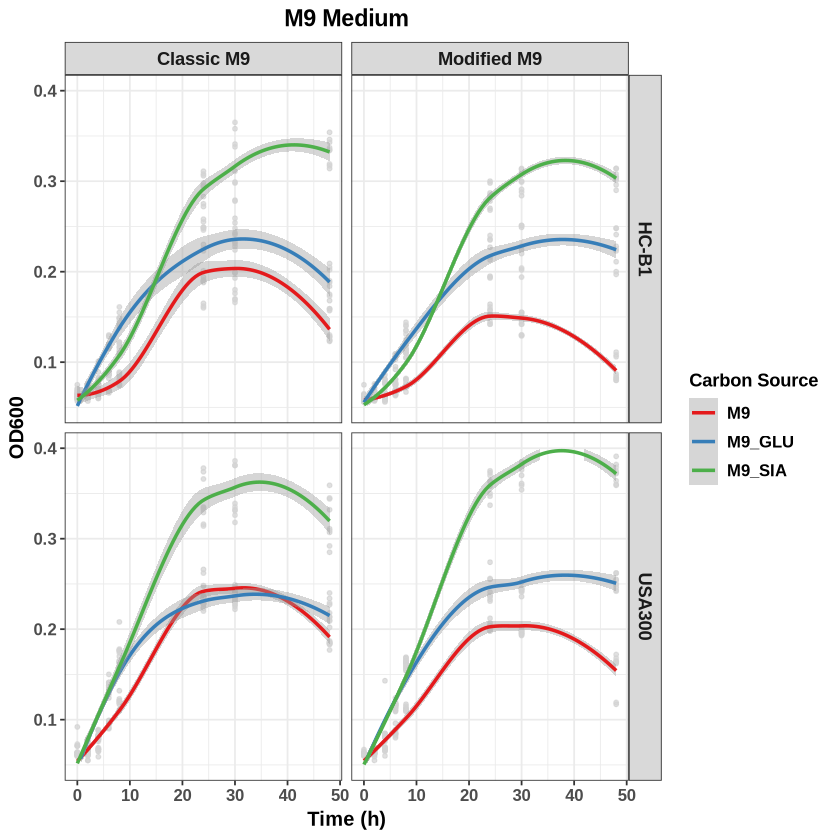

In [14]:
plotA <- ggplot(
  od_tp_long %>%
    filter(
      !is.na(Carbon),
      Strain != "Blank"
    ),
  aes(x = Time_hr, y = OD)
) +
  ## Raw well-level measurements
  geom_point(
    aes(group = Well),
    color = "lightgray",
    size  = 1.0,
    alpha = 0.7
  ) +
  
  ## LOESS trend per carbon source
  geom_smooth(
    aes(color = Carbon, group = Carbon),
    method = "loess",
    span   = 0.8,
    se     = TRUE,
    size   = 1
  ) +
  
  ## Facet by strain (rows) and medium (columns)
  facet_grid(
    Strain ~ Medium,
    scales = "free_y"
  ) +
  
  ## Color palette for carbon sources
  scale_color_brewer(palette = "Set1") +
  
  ## Labels and title
  labs(
    x     = "Time (h)",
    y     = "OD600",
    color = "Carbon Source",
    title = "M9 Medium", 
  ) +
  scale_y_continuous(limits = c(0.05, 0.4)) +  # fix y-axis across all facets

  
  ## Theme
  theme_bw() +
  theme(
    axis.title   = element_text(face = "bold", size = 12),
    axis.text    = element_text(face = "bold", size = 10),
    strip.text   = element_text(face = "bold", size = 11),
    legend.title = element_text(face = "bold", size = 11),
    legend.text  = element_text(face = "bold", size = 10),
    plot.title   = element_text(face = "bold", size = 14, hjust = 0.5)
  )

plotA

In [15]:
ggsave(
  filename = "growth_curves_M9_classic_vs_modified.png",
  plot     = plotA,
  width    = 10,
  height   = 6,
  units    = "in"
)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_smooth()`).”


In [16]:
############################################################
## µmax estimation from growth curves
## Method: maximum slope of ln(OD) vs Time
############################################################

library(dplyr)
library(tidyr)
library(purrr)

## ---- Function to estimate µmax for a single well ----
estimate_mu <- function(df) {

  df <- df %>%
    arrange(Time_hr) %>%
    filter(OD > 0)

  ## Require enough points to estimate slope
  if (nrow(df) < 4) return(NA_real_)

  ## Log-transform OD
  df <- df %>%
    mutate(logOD = log(OD))

  ## Compute discrete slopes between consecutive time points
  slopes <- diff(df$logOD) / diff(df$Time_hr)

  ## Return maximum slope (µmax)
  max(slopes, na.rm = TRUE)
}

## ---- Apply µmax estimation per well ----
mu_well <- od_tp_long %>%
  filter(
    Strain != "Blank",
    !is.na(Carbon),
    OD > 0
  ) %>%
  group_by(
    Medium,
    Strain,
    Carbon,
    Well
  ) %>%
  summarise(
    mu_max = estimate_mu(cur_data()),
    .groups = "drop"
  )


Warning message:
“There was 1 warning in `summarise()`.
ℹ In argument: `mu_max = estimate_mu(cur_data())`.
ℹ In group 1: `Medium = "Classic M9"`, `Strain = "HC-B1"`, `Carbon = "M9"`, `Well = "E7"`.
Caused by warning:
! `cur_data()` was deprecated in dplyr 1.1.0.
ℹ Please use `pick()` instead.”


In [17]:
mu_well

Medium,Strain,Carbon,Well,mu_max
<chr>,<chr>,<chr>,<chr>,<dbl>
Classic M9,HC-B1,M9,E7,0.12649826
Classic M9,HC-B1,M9,E8,0.13456433
Classic M9,HC-B1,M9,E9,0.05639775
Classic M9,HC-B1,M9,F7,0.12891455
Classic M9,HC-B1,M9,F8,0.07396007
Classic M9,HC-B1,M9,F9,0.06988097
Classic M9,HC-B1,M9,G7,0.11741980
Classic M9,HC-B1,M9,G8,0.08630637
Classic M9,HC-B1,M9,G9,0.05561282


In [18]:
############################################################
## Aggregate technical replicates
############################################################

mu_summary <- mu_well %>%
  group_by(
    Medium,
    Strain,
    Carbon
  ) %>%
  summarise(
    mu_mean = mean(mu_max, na.rm = TRUE),
    mu_sd   = sd(mu_max, na.rm = TRUE),
    n       = sum(!is.na(mu_max)),
    .groups = "drop"
  )
mu_summary

Medium,Strain,Carbon,mu_mean,mu_sd,n
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>
Classic M9,HC-B1,M9,0.09439499,0.03239933,9
Classic M9,HC-B1,M9_GLU,0.21220418,0.02079454,9
Classic M9,HC-B1,M9_SIA,0.15961690,0.04364133,9
Classic M9,USA300,M9,0.18185922,0.02660061,9
Classic M9,USA300,M9_GLU,0.26116870,0.03112776,9
Classic M9,USA300,M9_SIA,0.25000398,0.03044264,9
Modified M9,HC-B1,M9,0.08131503,0.02513734,9
Modified M9,HC-B1,M9_GLU,0.14753017,0.01965229,9
Modified M9,HC-B1,M9_SIA,0.18036759,0.01904590,9


In [20]:
############################################################
## Statistical comparison between media
############################################################

mu_stats <- mu_well %>%
  group_by(
    Strain,
    Carbon
  ) %>%
  summarise(
    p_value = wilcox.test(
      mu_max ~ Medium,
      exact = FALSE
    )$p.value,
    .groups = "drop"
  ) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH")
  )
mu_stats

Strain,Carbon,p_value,p_adj
<chr>,<chr>,<dbl>,<dbl>
HC-B1,M9,0.4267767365,0.426776737
HC-B1,M9_GLU,0.0004094601,0.002456761
HC-B1,M9_SIA,0.0168330921,0.020199711
USA300,M9,0.0061138114,0.009250131
USA300,M9_GLU,0.0061667542,0.009250131
USA300,M9_SIA,0.0035514648,0.009250131


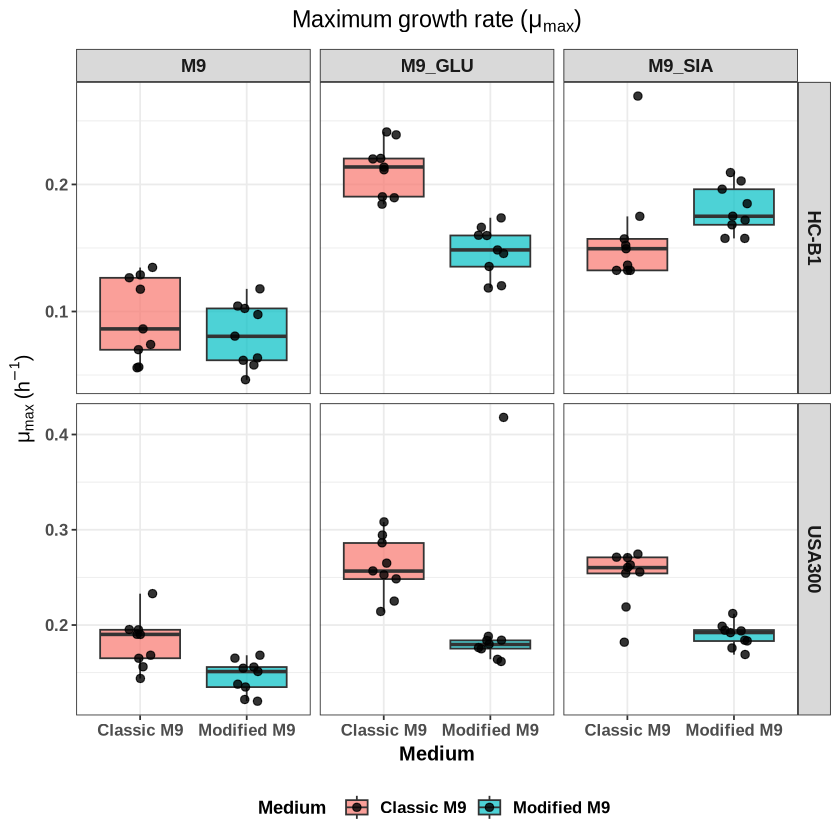

In [22]:
############################################################
## Plot µmax comparison
############################################################
plot_mu <- ggplot(
  mu_well,
  aes(x = Medium, y = mu_max, fill = Medium)
) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +
  geom_jitter(width = 0.15, size = 2, alpha = 0.8) +
  facet_grid(Strain ~ Carbon, scales = "free_y") +
  labs(
    x = "Medium",
    y = expression(mu[max]~"(h"^{-1}*")"),
    title = expression("Maximum growth rate ("*mu[max]*")")
  ) +
  theme_bw() +
  theme(
    ## Global text
    text = element_text(face = "bold"),

    ## Axis-specific
    axis.title = element_text(size = 12),
    axis.text  = element_text(size = 10),

    ## Facet strips
    strip.text = element_text(size = 11),

    ## Legend
    legend.position = "bottom",
    legend.title    = element_text(size = 11),
    legend.text     = element_text(size = 10),

    ## Plot title
    plot.title = element_text(size = 14, hjust = 0.5)
  )

plot_mu

In [23]:
ggsave(
  filename = "growth_rates_M9_classic_vs_modified.png",
  plot     = plot_mu,
  width    = 10,
  height   = 6,
  units    = "in"
)

In [25]:
############################################################
## Prepare statistics table for annotation
############################################################

library(dplyr)

mu_stats_plot <- mu_well %>%
  group_by(Strain, Carbon) %>%
  summarise(
    p_value = wilcox.test(mu_max ~ Medium, exact = FALSE)$p.value,
    .groups = "drop"
  ) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH"),
    label = case_when(
      p_adj < 0.001 ~ "***",
      p_adj < 0.01  ~ "**",
      p_adj < 0.05  ~ "*",
      TRUE          ~ "ns"
    ),

    ## Define comparison groups explicitly
    group1 = "Classic M9",
    group2 = "Modified M9"
  )
mu_stats_plot

Strain,Carbon,p_value,p_adj,label,group1,group2
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
HC-B1,M9,0.4267767365,0.426776737,ns,Classic M9,Modified M9
HC-B1,M9_GLU,0.0004094601,0.002456761,**,Classic M9,Modified M9
HC-B1,M9_SIA,0.0168330921,0.020199711,*,Classic M9,Modified M9
USA300,M9,0.0061138114,0.009250131,**,Classic M9,Modified M9
USA300,M9_GLU,0.0061667542,0.009250131,**,Classic M9,Modified M9
USA300,M9_SIA,0.0035514648,0.009250131,**,Classic M9,Modified M9


In [29]:
############################################################
## Compute y positions per Strain × Carbon
############################################################

y_pos <- mu_well %>%
  group_by(Strain, Carbon) %>%
  summarise(
    y.position = max(mu_max, na.rm = TRUE) * 1.15,
    .groups = "drop"
  )

mu_stats_plot2 <- mu_stats_plot %>%
  left_join(y_pos, by = c("Strain", "Carbon"))


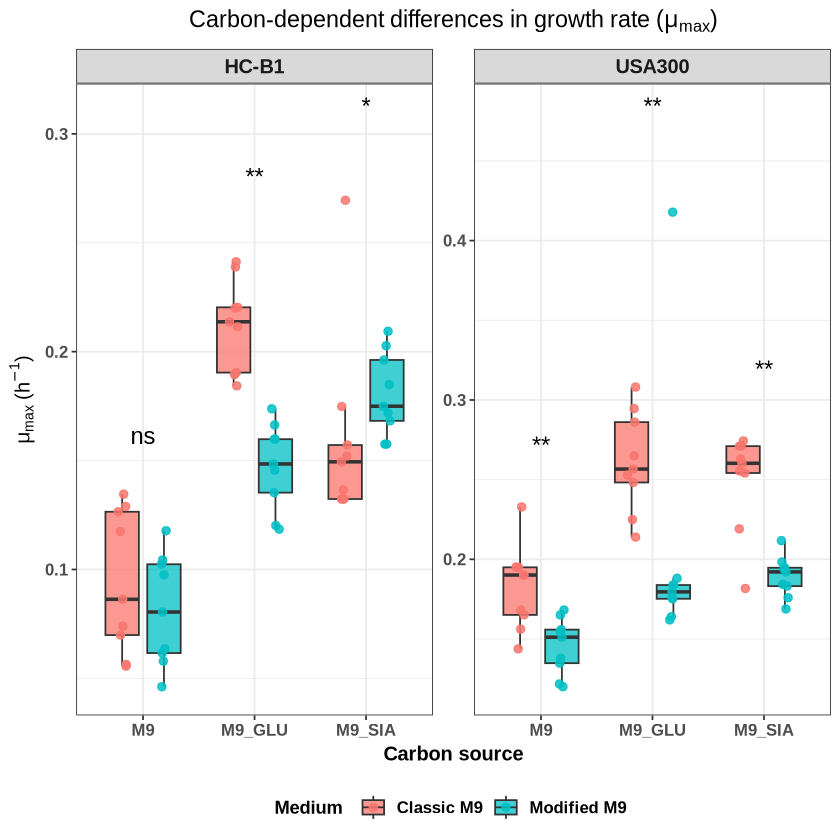

In [30]:
############################################################
## µmax comparison per carbon source
############################################################

library(ggplot2)
library(ggpubr)
library(dplyr)

plot_mu_carbon <- ggplot(
  mu_well,
  aes(x = Carbon, y = mu_max, fill = Medium)
) +
  ## Boxplots per medium
  geom_boxplot(
    position = position_dodge(width = 0.75),
    width = 0.6,
    alpha = 0.75,
    outlier.shape = NA
  ) +
  
  ## Individual well-level points
  geom_jitter(
    aes(color = Medium),
    position = position_jitterdodge(
      jitter.width = 0.15,
      dodge.width  = 0.75
    ),
    size = 2,
    alpha = 0.85
  ) +
  
  ## Statistical significance (Classic vs Modified per carbon)
  stat_pvalue_manual(
    mu_stats_plot2,
    label = "label",
    xmin = "Carbon",
    xmax = "Carbon",
    y.position = "y.position",
    tip.length = 0,
    size = 5
  ) +
  
  facet_wrap(~Strain, scales = "free_y") +
  labs(
    x = "Carbon source",
    y = expression(mu[max]~"(h"^{-1}*")"),
    fill  = "Medium",
    color = "Medium",
    title = expression("Carbon-dependent differences in growth rate ("*mu[max]*")")
  ) +
  theme_bw() +
  theme(
    text = element_text(face = "bold"),
    axis.title = element_text(size = 12),
    axis.text  = element_text(size = 10),
    strip.text = element_text(size = 12),
    legend.position = "bottom",
    legend.title = element_text(size = 11),
    legend.text  = element_text(size = 10),
    plot.title = element_text(size = 14, hjust = 0.5)
  )

plot_mu_carbon


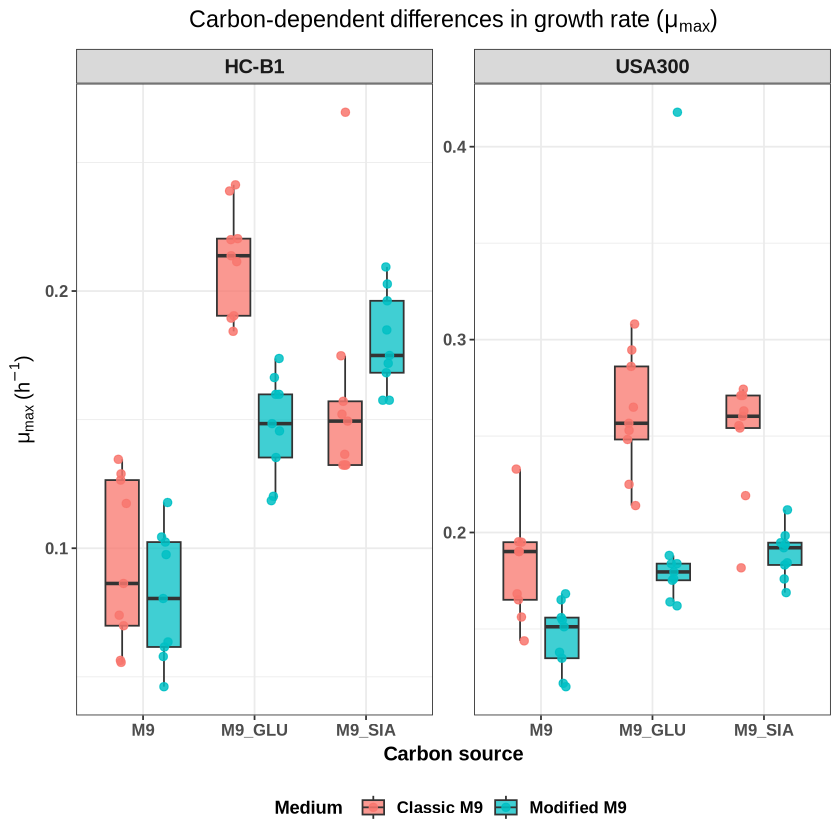

In [31]:
############################################################
## µmax comparison per carbon source (no stats annotation)
############################################################

library(ggplot2)
library(dplyr)

plot_mu_carbon_clean <- ggplot(
  mu_well,
  aes(x = Carbon, y = mu_max, fill = Medium)
) +
  ## Boxplots per medium
  geom_boxplot(
    position = position_dodge(width = 0.75),
    width = 0.6,
    alpha = 0.75,
    outlier.shape = NA
  ) +
  
  ## Individual well-level points
  geom_jitter(
    aes(color = Medium),
    position = position_jitterdodge(
      jitter.width = 0.15,
      dodge.width  = 0.75
    ),
    size = 2,
    alpha = 0.85
  ) +
  
  ## Facet by strain
  facet_wrap(~Strain, scales = "free_y") +
  
  ## Labels
  labs(
    x = "Carbon source",
    y = expression(mu[max]~"(h"^{-1}*")"),
    fill  = "Medium",
    color = "Medium",
    title = expression("Carbon-dependent differences in growth rate ("*mu[max]*")")
  ) +
  
  ## Theme
  theme_bw() +
  theme(
    text = element_text(face = "bold"),
    axis.title = element_text(size = 12),
    axis.text  = element_text(size = 10),
    strip.text = element_text(size = 12),
    legend.position = "bottom",
    legend.title = element_text(size = 11),
    legend.text  = element_text(size = 10),
    plot.title = element_text(size = 14, hjust = 0.5)
  )

plot_mu_carbon_clean


In [33]:
ggsave(
  filename = "growth_rates_M9_PERCARB-modifxclassic2.png",
  plot     = plot_mu_carbon_clean,
  width    = 10,
  height   = 6,
  units    = "in"
)